In [1]:
import numpy as np
import pandas as pd
import mdtraj as md

import os 
import sys

import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
CorrFuncLOC = 'D:/Users/Alan/Documents/Research/DiffusionTip4pDSoluteSize/'
CorrFuncLoc2 = 'E:/Research/LangevinDynamics_RotationalDiffusion/'
ENSEMBLES = ['NVE', 'NVT']
CouplingFrequency = ['CF0-2ps', 'CF2ps', 'CF20ps']
RUNS = ['Run{}'.format(n) for n in range(1,5,1)]
Proteins = ['GB3', 'Ubiquitin']
MINDX = pd.MultiIndex.from_product([Proteins, ENSEMBLES])
MINDX_NVT=pd.MultiIndex.from_product([Proteins, CouplingFrequency])
LocDF_NVE = pd.DataFrame(index=RUNS, columns=MINDX)
LocDF_NVE_R2 = LocDF_NVE.copy()
LocDF_NVT = pd.DataFrame(index=RUNS, columns=MINDX_NVT)
FileLocDict = {}

In [3]:
for items, values in LocDF_NVT.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVT.loc[indx, items] = '{}{}/PROD_NVT/{}/{}'.format(CorrFuncLoc2, items[0], items[1], indx)
        
for items, values in LocDF_NVE.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVE.loc[indx, items] = '{}{}/PROD_{}/{}'.format(CorrFuncLoc2, items[0], items[1], indx)

('GB3', 'CF0-2ps')
('GB3', 'CF2ps')
('GB3', 'CF20ps')
('Ubiquitin', 'CF0-2ps')
('Ubiquitin', 'CF2ps')
('Ubiquitin', 'CF20ps')
('GB3', 'NVE')
('GB3', 'NVT')
('Ubiquitin', 'NVE')
('Ubiquitin', 'NVT')


In [4]:
for items, values in LocDF_NVE_R2.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVE_R2.loc[indx, items] = '{}{}/PROD_{}_Run2/{}'.format(CorrFuncLoc2, items[0], items[1], indx)

('GB3', 'NVE')
('GB3', 'NVT')
('Ubiquitin', 'NVE')
('Ubiquitin', 'NVT')


In [5]:
LocDF_NVE_R2

GB3  \
                                                    NVE   
Run1  E:/Research/LangevinDynamics_RotationalDiffusi...   
Run2  E:/Research/LangevinDynamics_RotationalDiffusi...   
Run3  E:/Research/LangevinDynamics_RotationalDiffusi...   
Run4  E:/Research/LangevinDynamics_RotationalDiffusi...   

                                                         \
                                                    NVT   
Run1  E:/Research/LangevinDynamics_RotationalDiffusi...   
Run2  E:/Research/LangevinDynamics_RotationalDiffusi...   
Run3  E:/Research/LangevinDynamics_RotationalDiffusi...   
Run4  E:/Research/LangevinDynamics_RotationalDiffusi...   

                                              Ubiquitin  \
                                                    NVE   
Run1  E:/Research/LangevinDynamics_RotationalDiffusi...   
Run2  E:/Research/LangevinDynamics_RotationalDiffusi...   
Run3  E:/Research/LangevinDynamics_RotationalDiffusi...   
Run4  E:/Research/LangevinDynamics_RotationalDiffusi...   

                                                         
                                                    NVT  
Run1  E:/Research/LangevinDynamics_RotationalDiffusi...  
Run2  E:/Research/LangevinDynamics_RotationalDiffusi...  
Run3  E:/Research/LangevinDynamics_RotationalDiffusi...  
Run4  E:/Research/LangevinDynamics_RotationalDiffusi...

In [6]:
LocDF_NVT['Ubiquitin'].iloc[0,0]

'E:/Research/LangevinDynamics_RotationalDiffusion/Ubiquitin/PROD_NVT/CF0-2ps/Run1'

In [7]:
LocDF_NVE.loc['Run1',('GB3','NVE')]

'E:/Research/LangevinDynamics_RotationalDiffusion/GB3/PROD_NVE/Run1'

In [9]:
GB3Top = md.load_prmtop('{}GB3/GB3_2Na_FF14SB.prmtop'.format(CorrFuncLoc2))
GB3HInd = GB3Top.select('name CA and protein')
GB3Hatom_name = pd.Series(['{}'.format(GB3Top.atom(atmx)) for atmx in GB3HInd])
GB3atom_df = GB3Hatom_name.str.split('-',expand=True).rename(columns={0:'RESNAME',1:'ATMNAME'})
GB3atom_df['RESNAME'] = GB3atom_df['RESNAME'].apply(lambda rr: '{}'.format(rr[:3] + str(int(rr[3:])+1)))
GB3atom_df['RESID'] = GB3atom_df['RESNAME'].apply(lambda rr: int(rr[3:]))

In [14]:
UBQTop = md.load_prmtop('{}Ubiquitin/PROD_noH2O.UBQ_10mMNaCl_FF14SB.prmtop'.format(CorrFuncLoc2))
UBQHInd = UBQTop.select('name CA and protein')
UBQHatom_name = pd.Series(['{}'.format(UBQTop.atom(atmx)) for atmx in UBQHInd])
UBQatom_df = UBQHatom_name.str.split('-',expand=True).rename(columns={0:'RESNAME',1:'ATMNAME'})
UBQatom_df['RESNAME'] = UBQatom_df['RESNAME'].apply(lambda rr: '{}'.format(rr[:3] + str(int(rr[3:])+1)))
UBQatom_df['RESID'] = UBQatom_df['RESNAME'].apply(lambda rr: int(rr[3:]))

## Secondary Structure

In [ ]:
AMBDSSPDICT = {0:'Coil',1:r'Parallel $\beta$-sheet',2:r'Anti-Parallel $\beta$-sheet', 3:'3-10 Helix' ,
                    4:r'$\alpha$-helix', 5:r'$\pi$-helix', 6:'Turn', 7:'Bend', 8:'PPII'}
AMBDSSP_DICT = {'Para':r'Parallel $\beta$-sheet', 'Anti':r'Anti-Parallel $\beta$-sheet', '3-10':'3-10 Helix',
                'Alpha':r'$\alpha$-helix', 'Pi':r'$\pi$-helix', 'Turn':'Turn', 'Bend':'Bend'}

In [ ]:
tseriesdf = pd.read_csv('{}/GB3_SS.dat'.format(LocDF_NVE.loc['Run1',('GB3','NVE')]),index_col=0,delim_whitespace=True)

In [ ]:
def _read_DSSPSum(loc_df, fname, protein, ensemble, coupling=None):
    
    sim_mindx = pd.MultiIndex.from_product([loc_df.index.values, list(AMBDSSP_DICT.values())])
    
    indexdf = pd.read_csv('{}/{}'.format(loc_df[protein].iloc[0,0], fname),
                     index_col=0, delim_whitespace=True,usecols=[0])
    
    sim_DSSP_sumDF = pd.DataFrame(index=indexdf.index.values, columns=sim_mindx).fillna(0.0)
    
    for rind in loc_df.index:
    
        if ensemble == 'NVE':
            sumdf = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, ensemble)], fname),
                            index_col=0, delim_whitespace=True)
        elif ensemble == 'NVT':
            sumdf = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, coupling)], fname),
                            index_col=0, delim_whitespace=True)
            
        sumdf = sumdf.rename(columns = AMBDSSP_DICT)
        indxcol = [(rind,cc) for cc in sumdf.columns]
        sim_DSSP_sumDF.loc[sumdf.index.values, indxcol] = sumdf.values
        
    return sim_DSSP_sumDF

In [ ]:
gb3_sumdf_nve = _read_DSSPSum(LocDF_NVE, 'GB3_SS_Sum.out', 'GB3', 'NVE')
gb3_sumdf_nvt_cf02ps = _read_DSSPSum(LocDF_NVT, 'GB3_SS_Sum.out', 'GB3', 'NVT', coupling='CF0-2ps')
gb3_sumdf_nvt_cf2ps  = _read_DSSPSum(LocDF_NVT,  'GB3_SS_Sum.out', 'GB3', 'NVT', coupling='CF2ps')
gb3_sumdf_nvt_cf20ps = _read_DSSPSum(LocDF_NVT, 'GB3_SS_Sum.out', 'GB3', 'NVT', coupling='CF20ps')

In [ ]:
ubq_sumdf_nve = _read_DSSPSum(LocDF_NVE, 'UBQ_SS_Sum.out', 'Ubiquitin', 'NVE')
ubq_sumdf_nvt_cf02ps = _read_DSSPSum(LocDF_NVT, 'UBQ_SS_Sum.out', 'Ubiquitin', 'NVT', coupling='CF0-2ps')
ubq_sumdf_nvt_cf2ps  = _read_DSSPSum(LocDF_NVT,  'UBQ_SS_Sum.out', 'Ubiquitin', 'NVT', coupling='CF2ps')
ubq_sumdf_nvt_cf20ps = _read_DSSPSum(LocDF_NVT, 'UBQ_SS_Sum.out', 'Ubiquitin', 'NVT', coupling='CF20ps')

In [ ]:
gb3_sumdf_nve_R2 = _read_DSSPSum(LocDF_NVE_R2, 'GB3_SS_Sum.out', 'GB3', 'NVE')
ubq_sumdf_nve_R2 = _read_DSSPSum(LocDF_NVE_R2, 'UBQ_SS_Sum.out', 'Ubiquitin', 'NVE')

In [ ]:
opt_gb3_sumdf = gb3_sumdf_nve['Run3'].copy()
for optttf in [gb3_sumdf_nve['Run4'], gb3_sumdf_nve_R2['Run2'], gb3_sumdf_nve_R2['Run3']]:
    
    opt_gb3_sumdf += optttf

opt_gb3_sumdf = ((opt_gb3_sumdf)/4).drop(columns=['3-10 Helix',r'$\pi$-helix','Bend'])

In [ ]:
opt_ubq_sumdf = ubq_sumdf_nve['Run1'].copy()
for optttf in [ubq_sumdf_nve['Run3'], ubq_sumdf_nve_R2['Run2'], ubq_sumdf_nve_R2['Run3']]:
    
    opt_ubq_sumdf += optttf

opt_ubq_sumdf = ((opt_ubq_sumdf)/4).drop(columns=['3-10 Helix',r'$\pi$-helix','Bend'])

In [ ]:
fig_gb3_dssp, axgb3dssp = plt.subplots(2,1, figsize=(12,12), sharex=True)
fig_gb3_dssp.subplots_adjust(hspace=0.025)

axgb3dssp_nve = axgb3dssp[0]
axgb3dssp_nve.set_xlim(0.0,55.0)
axgb3dssp_nve.set_ylim(-0.05,1.15)
opt_gb3_sumdf.plot.bar(ax=axgb3dssp_nve, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k')
axgb3dssp_nve.legend(ncol=4, mode='expand', frameon=False, prop={'size':15, 'weight':'bold'})
axgb3dssp_nve.tick_params(labelsize=15)
axgb3dssp_nve.set_yticks(np.arange(0.0, 1.1, 0.10))

axgb3dssp_nvt = axgb3dssp[1]
gb3_sumdf_nvt_cf2ps_avg = gb3_sumdf_nvt_cf2ps.mean(axis=1,level=1).drop(columns=['3-10 Helix',r'$\pi$-helix','Bend'])
axgb3dssp_nvt.set_xlim(0.0,55.0)
axgb3dssp_nvt.set_ylim(-0.05,1.05)
gb3_sumdf_nvt_cf2ps_avg.plot.bar(ax=axgb3dssp_nvt, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k', legend=False)
axgb3dssp_nvt.tick_params(labelsize=15)
axgb3dssp_nvt.set_yticks(np.arange(0.0, 1.1, 0.10))
axgb3dssp_nvt.set_xticklabels(GB3atom_df['RESNAME'].values, rotation=90)

fig_gb3_dssp.savefig('{}/GB3/Analysis/CompareSecondaryStructure_NVE_NVTCf2ps.png'.format(CorrFuncLoc2),
                     dpi=600, bbox_inches='tight')

In [ ]:
fig_gb3_dssp, axgb3dssp = plt.subplots(4,1, figsize=(12,20), sharex=True, num=20193)
fig_gb3_dssp.subplots_adjust(hspace=0.125)

axgb3dssp_nve = axgb3dssp[0]
axgb3dssp_nve.set_xlim(0.0,55.0)
axgb3dssp_nve.set_ylim(-0.05,1.20)
opt_gb3_sumdf.plot.bar(ax=axgb3dssp_nve, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k')
axgb3dssp_nve.legend(ncol=4, mode='expand', frameon=False, prop={'size':15, 'weight':'bold'})
axgb3dssp_nve.tick_params(labelsize=15)
axgb3dssp_nve.set_yticks(np.arange(0.0, 1.1, 0.10))
axgb3dssp_nve.set_title(r'$\mathbf{NVE}$', fontsize=16)
nvt_labels = [r'$\mathbf{ NVT : \gamma = 0.2 \ \ ps^{-1}}$', 
              r'$\mathbf{ NVT : \gamma = 2 \ \ ps^{-1}}$',
              r'$\mathbf{ NVT : \gamma = 20 \ \ ps^{-1}}$']

for axnvt, data, text_title in zip(axgb3dssp[1:],[gb3_sumdf_nvt_cf02ps, gb3_sumdf_nvt_cf2ps, gb3_sumdf_nvt_cf20ps], nvt_labels):
    nvt_avg = data.mean(axis=1,level=1).drop(columns=['3-10 Helix',r'$\pi$-helix','Bend'])
    axnvt.set_xlim(0.0,55.0)
    axnvt.set_ylim(-0.05,1.15)
    nvt_avg.plot.bar(ax=axnvt, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k', legend=False)
    axnvt.tick_params(labelsize=15)
    axnvt.set_yticks(np.arange(0.0, 1.1, 0.10))
    axnvt.set_title(text_title, fontsize=16)
    
axgb3dssp[3].set_xticklabels(GB3atom_df['RESNAME'].values, rotation=90)

fig_gb3_dssp.savefig('{}/GB3/Analysis/CompareSecondaryStructure_NVE_AllNVT.png'.format(CorrFuncLoc2),
                     dpi=600, bbox_inches='tight')

In [ ]:
fig_ubq_dssp, axubqdssp = plt.subplots(4,1, figsize=(14,20), sharex=True, num=20195)
fig_ubq_dssp.subplots_adjust(hspace=0.125)

axubqdssp_nve = axubqdssp[0]
axubqdssp_nve.set_xlim(0.0,55.0)
axubqdssp_nve.set_ylim(-0.05,1.20)
opt_ubq_sumdf.plot.bar(ax=axubqdssp_nve, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k')
axubqdssp_nve.legend(ncol=4, mode='expand', frameon=False, prop={'size':15, 'weight':'bold'})
axubqdssp_nve.tick_params(labelsize=15)
axubqdssp_nve.set_yticks(np.arange(0.0, 1.1, 0.10))
axubqdssp_nve.set_title(r'$\mathbf{NVE}$', fontsize=16)
nvt_labels = [r'$\mathbf{ NVT : \gamma = 0.2 \ \ ps^{-1}}$', 
              r'$\mathbf{ NVT : \gamma = 2 \ \ ps^{-1}}$',
              r'$\mathbf{ NVT : \gamma = 20 \ \ ps^{-1}}$']

for axnvt, data, text_title in zip(axubqdssp[1:],[ubq_sumdf_nvt_cf02ps, ubq_sumdf_nvt_cf2ps, ubq_sumdf_nvt_cf20ps], nvt_labels):
    nvt_avg = data.mean(axis=1,level=1).drop(columns=['3-10 Helix',r'$\pi$-helix','Bend'])
    axnvt.set_xlim(0.0,55.0)
    axnvt.set_ylim(-0.05,1.15)
    nvt_avg.plot.bar(ax=axnvt, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k', legend=False)
    axnvt.tick_params(labelsize=15)
    axnvt.set_yticks(np.arange(0.0, 1.1, 0.10))
    axnvt.set_title(text_title, fontsize=16)
    
axubqdssp[3].set_xticklabels(UBQatom_df['RESNAME'].values, rotation=90)

fig_ubq_dssp.savefig('{}/Ubiquitin/Analysis/CompareSecondaryStructure_NVE_AllNVT.png'.format(CorrFuncLoc2),
                     dpi=600, bbox_inches='tight')

In [ ]:
fig_ubq_dssp, axubqdssp = plt.subplots(4,1, figsize=(14,20), sharex=True, num=20195)
fig_ubq_dssp.subplots_adjust(hspace=0.125)

axubqdssp_nve = axubqdssp[0]
axubqdssp_nve.set_xlim(0.0,55.0)
axubqdssp_nve.set_ylim(-0.05,1.20)
opt_ubq_sumdf.plot.bar(ax=axubqdssp_nve, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k')
axubqdssp_nve.legend(ncol=4, mode='expand', frameon=False, prop={'size':15, 'weight':'bold'})
axubqdssp_nve.tick_params(labelsize=15)
axubqdssp_nve.set_yticks(np.arange(0.0, 1.1, 0.10))
axubqdssp_nve.set_title(r'$\mathbf{NVE}$', fontsize=16)
nvt_labels = [r'$\mathbf{ NVT : \gamma = 0.2 \ \ ps^{-1}}$', 
              r'$\mathbf{ NVT : \gamma = 2 \ \ ps^{-1}}$',
              r'$\mathbf{ NVT : \gamma = 20 \ \ ps^{-1}}$']

for axnvt, data, text_title in zip(axubqdssp[1:],[ubq_sumdf_nvt_cf02ps, ubq_sumdf_nvt_cf2ps, ubq_sumdf_nvt_cf20ps], nvt_labels):
    nvt_avg = data.mean(axis=1,level=1).drop(columns=['3-10 Helix',r'$\pi$-helix','Bend'])
    axnvt.set_xlim(0.0,55.0)
    axnvt.set_ylim(-0.05,1.15)
    nvt_avg.plot.bar(ax=axnvt, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k', legend=False)
    axnvt.tick_params(labelsize=15)
    axnvt.set_yticks(np.arange(0.0, 1.1, 0.10))
    axnvt.set_title(text_title, fontsize=16)
    
axubqdssp[3].set_xticklabels(UBQatom_df['RESNAME'].values, rotation=90)

fig_ubq_dssp.savefig('{}/Ubiquitin/Analysis/CompareSecondaryStructure_NVE_AllNVT.png'.format(CorrFuncLoc2),
                     dpi=600, bbox_inches='tight')

In [ ]:
ubq_sumdf_nvt_cf02ps

In [ ]:
ubq_sumdf_nve.mean(axis=1,level=1).drop(columns=['3-10 Helix',r'$\pi$-helix','Turn','Bend']).plot(cmap='Dark2')

In [ ]:


gb3_sumdf_nve.mean(axis=1,level=1).drop(columns=[r'$\pi$-helix','Turn','Bend']).plot()
gb3_sumdf_nvt_cf2ps.mean(axis=1,level=1).drop(columns=[r'$\pi$-helix','Turn','Bend']).plot(ax=plt.gca())

In [ ]:
testdf = pd.read_csv('{}/GB3_SS_sum.out'.format(LocDF_NVE.loc[RIND,('GB3','NVE')]),
                     index_col=0, delim_whitespace=True,usecols=[0])

In [ ]:
RMINDX = pd.MultiIndex.from_product([LocDF_NVE.index.values, list(AMBDSSP_DICT.values())])
gb3_sumdf_nve = pd.DataFrame(index = np.arange(1,57,1), columns = RMINDX).fillna(0.0)

In [ ]:
RMINDX = pd.MultiIndex.from_product([LocDF_NVE.index.values, list(AMBDSSP_DICT.values())])
for RIND in gb3_sumdf_nve.columns.levels[0]:
    sumdf = pd.read_csv('{}/GB3_SS_sum.out'.format(LocDF_NVE.loc[RIND,('GB3','NVE')]), index_col=0, delim_whitespace=True)
    sumdf = sumdf.rename(columns = AMBDSSP_DICT)
    indxcol = [(RIND,cc) for cc in sumdf.columns]
    gb3_sumdf_nve.loc[sumdf.index.values, indxcol] = sumdf.values

In [ ]:
RMINDX = pd.MultiIndex.from_product([LocDF_NVE.index.values, list(AMBDSSP_DICT.values())])
for RIND in gb3_sumdf_nve.columns.levels[0]:
    sumdf = pd.read_csv('{}/GB3_SS_sum.out'.format(LocDF_NVE.loc[RIND,('GB3','NVE')]), index_col=0, delim_whitespace=True)
    sumdf = sumdf.rename(columns = AMBDSSP_DICT)
    indxcol = [(RIND,cc) for cc in sumdf.columns]
    gb3_sumdf_nve.loc[sumdf.index.values, indxcol] = sumdf.values

In [ ]:
gb3_sumdf_nve.mean(axis=1,level=1).plot()

In [ ]:
sumdf.plot()

## RMSD

In [10]:
def _read_RMSD(loc_df, fname, protein, ensemble, coupling=None, nsnaps=1000000):

    
    sim_RMSDDF = pd.DataFrame(index=np.arange(1, nsnaps+1, 1), columns=loc_df.index.values).fillna(0.0)
    
    for rind in loc_df.index:
    
        if ensemble == 'NVE':
            rmsddf = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, ensemble)], fname),
                            index_col=0, delim_whitespace=True)
            
        elif ensemble == 'NVT':
            rmsddf = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, coupling)], fname),
                            index_col=0, delim_whitespace=True)
            
        sim_RMSDDF.loc[:,rind] = rmsddf
    
    sim_RMSDDF.index = sim_RMSDDF.index.values*0.0005
        
    return sim_RMSDDF

In [ ]:
RMSDDF_GB3_NVE = _read_RMSD(LocDF_NVE, 'Backbone_RMSD.dat', 'GB3', 'NVE', coupling=None, nsnaps=1000000 )
RMSDDF_GB3_NVT_Cf02ps = _read_RMSD(LocDF_NVT, 'Backbone_RMSD.dat', 'GB3', 'NVT', coupling='CF0-2ps', nsnaps=2000000 )
RMSDDF_GB3_NVT_Cf2ps = _read_RMSD(LocDF_NVT, 'Backbone_RMSD.dat', 'GB3', 'NVT', coupling='CF2ps', nsnaps=2000000 )
RMSDDF_GB3_NVT_Cf20ps = _read_RMSD(LocDF_NVT, 'Backbone_RMSD.dat', 'GB3', 'NVT', coupling='CF20ps', nsnaps=2000000 )

In [ ]:
RMSDDF_UBQ_NVE = _read_RMSD(LocDF_NVE, 'Backbone_RMSD.dat', 'Ubiquitin', 'NVE', coupling=None, nsnaps=1000000 )
RMSDDF_UBQ_NVT_Cf02ps = _read_RMSD(LocDF_NVT, 'Backbone_RMSD.dat', 'Ubiquitin', 'NVT', coupling='CF0-2ps', nsnaps=2000000 )
RMSDDF_UBQ_NVT_Cf2ps = _read_RMSD(LocDF_NVT, 'Backbone_RMSD.dat', 'Ubiquitin', 'NVT', coupling='CF2ps', nsnaps=2000000 )
RMSDDF_UBQ_NVT_Cf20ps = _read_RMSD(LocDF_NVT, 'Backbone_RMSD.dat', 'Ubiquitin', 'NVT', coupling='CF20ps', nsnaps=2000000 )

In [ ]:
RMSDDF_GB3_NVE_R2 = _read_RMSD(LocDF_NVE_R2, 'Backbone_RMSD.dat', 'GB3', 'NVE', coupling=None, nsnaps=1000000 )
RMSDDF_UBQ_NVE_R2 = _read_RMSD(LocDF_NVE_R2, 'Backbone_RMSD.dat', 'Ubiquitin', 'NVE', coupling=None, nsnaps=1000000 )

In [ ]:
RMSDDF_NVE = pd.DataFrame(index=np.arange(1,1000001,1), columns=RUNS).fillna(0.0)
for R in RUNS:
    rmsddf = pd.read_csv('{}/Backbone_RMSD.dat'.format(LocDF_NVE.loc[R, ('GB3','NVE')]),
                         index_col=0, delim_whitespace=True)
    RMSDDF_NVE.loc[:, R] = rmsddf.loc[RMSDDF_NVE.index.values,:]
    

In [ ]:
RMSDDF_NVT = pd.DataFrame(index=np.arange(1,2000001,1), columns=RUNS).fillna(0.0)
for R in RUNS:
    rmsddf = pd.read_csv('{}/Backbone_RMSD.dat'.format(LocDF_NVT.loc[R, ('GB3','CF0-2ps')]),
                         index_col=0, delim_whitespace=True)
    RMSDDF_NVT.loc[:, R] = rmsddf

In [ ]:
RMSDDF_NVT.plot.hist(bins=25, alpha=0.5, edgecolor='k')

In [ ]:
RMSDDF_NVT.mean()

In [ ]:
def BCF(res_qn0, res_an, res_bn, n, i):
    return 1 + (res_qn0 - 1)/(1 + res_an*abs(n-i) + res_bn*np.square(abs(n-i)) )

In [ ]:
seq = 'MRDRSPRSPRRERSP'
seq2var_dict = {''}

## SASA Calculation

In [11]:
def _read_SurfaceCalculation(protein, ensemble, atom_df, coupling='CF2ps'):
    
    runsmindx = pd.MultiIndex.from_product([RUNS, atom_df.RESID])
    
    surfalldf = pd.DataFrame(index=np.arange(1, 1000001, 1), columns=runsmindx).fillna(0.0)
    
    for rind in RUNS:
        print(rind)
        for resid in atom_df.RESID:
            #print(resid)
            if ensemble == 'NVE':
                fileloc = '{}{}/PROD_NVE/Analysis/{}/Surface/Surface_Res{}.dat'.format(CorrFuncLoc2, protein, rind, resid)
                surfdf = pd.read_csv(fileloc, delim_whitespace=True, index_col=0 )
        
            elif ensemble == 'NVE_Run2':
                fileloc = '{}{}/PROD_NVE_Run2/Analysis/{}/Surface/Surface_Res{}.dat'.format(CorrFuncLoc2, protein, rind, resid)
                surfdf = pd.read_csv(fileloc, delim_whitespace=True,  index_col=0)
            
            elif ensemble == 'NVT':
                fileloc = '{}{}/PROD_NVT/{}/{}/Surface/Surface_Res{}.dat'.format(CorrFuncLoc2, protein, coupling, rind, resid)
                surfdf = pd.read_csv(fileloc, delim_whitespace=True,  index_col=0 )
            
            surfalldf[(rind,resid)] = surfdf.loc[surfalldf.index.values, 'R{}'.format(resid)]
    
    return surfalldf

In [55]:
SURFAlldf_NVE = _read_SurfaceCalculation('GB3', 'NVE', GB3atom_df, coupling='CF0-2ps')
SURFAlldf_NVER2 = _read_SurfaceCalculation('GB3', 'NVE_Run2', GB3atom_df, coupling='CF0-2ps')

Run1
1


C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\numpy\lib\arraysetops.py:569: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
Run2
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
Run3
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
Run4
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
Run1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
Run2
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
Run3
1
2
3
4
5
6
7
8
9


In [12]:

SURFAlldf_NVER2 = _read_SurfaceCalculation('Ubiquitin', 'NVE_Run2', UBQatom_df, coupling='CF0-2ps')

Run1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
Run2
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
Run3
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
Run4
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76


In [14]:
SURFAlldf_NVE = _read_SurfaceCalculation('Ubiquitin', 'NVE', UBQatom_df, coupling='CF0-2ps')

Run1
1


C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\numpy\lib\arraysetops.py:569: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
Run2
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
Run3
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
Run4
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76


In [16]:
SURFAlldf_Cf02ps = _read_SurfaceCalculation('Ubiquitin', 'NVT', UBQatom_df, coupling='CF0-2ps')
SURFAlldf_Cf20ps = _read_SurfaceCalculation('Ubiquitin', 'NVT', UBQatom_df, coupling='CF20ps')

Run1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
Run2
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
Run3
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
Run4
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
Run1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36


In [17]:
SURFAlldf_Cf2ps = _read_SurfaceCalculation('Ubiquitin', 'NVT', UBQatom_df, coupling='CF2ps')

Run1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
Run2
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
Run3
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
Run4
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76


In [ ]:
SURFAlldf_Cf2ps_4plot = SURFAlldf_Cf2ps.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})
sns.lineplot(x='RESID', y='SASA', data=SURFAlldf_Cf2ps_4plot)

In [ ]:
surfdf = pd.read_csv('D:/Research/LangevinDynamics_RotationalDiffusion/Ubiquitin/PROD_NVE/Analysis/Run1/Surface/Surface_Res2.dat',
            delim_whitespace=True)

In [ ]:
SURFAlldf_4Plot = SURFAlldf.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})
sns.lineplot(x='RESID', y='SASA', data=SURFAlldf_4Plot)

In [ ]:
sns.heatmap(SURFAlldf.mean(axis=0).unstack().mean().reset_index())

In [46]:
def _plot_SASAHeatmap(plot_data, atom_df, fnum=32131):
    
    fig_SASA = plt.figure(91842, figsize=(16,2.0))
    cmapax = fig_SASA.add_axes([0.125,0.925,0.775,0.10])
    axSASA = fig_SASA.add_subplot(111)
    
    sasa_mean = plot_data.mean(axis=0).unstack().mean().values.reshape(1,-1)
    sasa_ref = sasa_mean/sasa_mean.max()
    cmap = axSASA.imshow(sasa_ref, cmap='viridis', aspect='auto')
    
    fig_SASA.colorbar(cmap, cax=cmapax,orientation='horizontal')
    axSASA.set_yticks([])
    axSASA.set_xticks(np.arange(0, atom_df.shape[0]+1,1))
    axSASA.set_xticklabels(atom_df.RESNAME, rotation=90)
    cmapax.xaxis.tick_top()
    cmapax.tick_params(labelsize=15)
    axSASA.tick_params(labelsize=14)
    cmapax.xaxis.set_label_position('top')
    cmapax.set_xlabel(r'$\mathbf{SASA/max(SASA) \ \ (\AA^{2})}$', fontsize=15)
    
    for j, val in enumerate(sasa_ref.flatten()):
        #print(j,val)
        text = axSASA.text(j, 0, '{:.2}'.format(val), ha="center", va="center", color="w", rotation=90, fontweight='bold')
    
    return fig_SASA

In [ ]:
def _plot_SASAHeatmap(plot_data, atom_df, fnum=32131):
    
    fig_SASA = plt.figure(91842, figsize=(16,2.0))
    cmapax = fig_SASA.add_axes([0.125,0.925,0.775,0.10])
    axSASA = fig_SASA.add_subplot(111)
    
    sasa_mean = plot_data.mean(axis=0).unstack().mean().values.reshape(1,-1)
    sasa_ref = sasa_mean/sasa_mean.max()
    cmap = axSASA.imshow(sasa_ref, cmap='viridis', aspect='auto')
    
    fig_SASA.colorbar(cmap, cax=cmapax,orientation='horizontal')
    axSASA.set_yticks([])
    axSASA.set_xticks(np.arange(0, atom_df.shape[0]+1,1))
    axSASA.set_xticklabels(atom_df.RESNAME, rotation=90)
    cmapax.xaxis.tick_top()
    cmapax.tick_params(labelsize=15)
    axSASA.tick_params(labelsize=14)
    cmapax.xaxis.set_label_position('top')
    cmapax.set_xlabel(r'$\mathbf{SASA/max(SASA) \ \ (\AA^{2})}$', fontsize=15)
    
    for j, val in enumerate(sasa_ref.flatten()):
        #print(j,val)
        text = axSASA.text(j, 0, '{:.2}'.format(val), ha="center", va="center", color="w", rotation=90, fontweight='bold')
    
    return fig_SASA

In [30]:
SURFAlldf_NVE_4Plot = SURFAlldf_NVE.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})
SURFAlldf_NVER2_4Plot = SURFAlldf_NVER2.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})
SURFAlldf_Cf02ps_4Plot = SURFAlldf_Cf02ps.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})
SURFAlldf_Cf2ps_4Plot = SURFAlldf_Cf2ps.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})
SURFAlldf_Cf02ps_4Plot = SURFAlldf_Cf20ps.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})

In [ ]:
SURFAlldf_NVER2

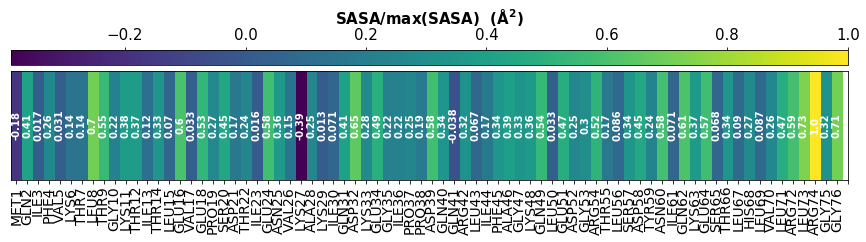

In [49]:
fig_SASA_NVER2 = _plot_SASAHeatmap(SURFAlldf_NVER2, UBQatom_df)
fig_SASA_NVER2.savefig('{}Ubiquitin/PROD_NVE_Run2/Analysis/SASA_Heatmap_Normalized.png'.format(CorrFuncLoc2),
                       dpi=600, bbox_inches='tight')

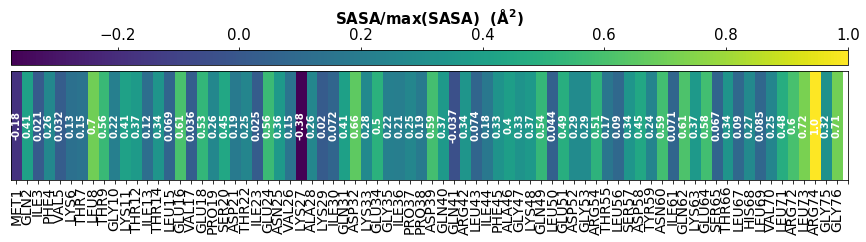

In [50]:
fig_SASA_NVE = _plot_SASAHeatmap(SURFAlldf_NVE, UBQatom_df)
fig_SASA_NVE.savefig('{}Ubiquitin/PROD_NVE/Analysis/SASA_Heatmap_Normalized.png'.format(CorrFuncLoc2),
                       dpi=600, bbox_inches='tight')

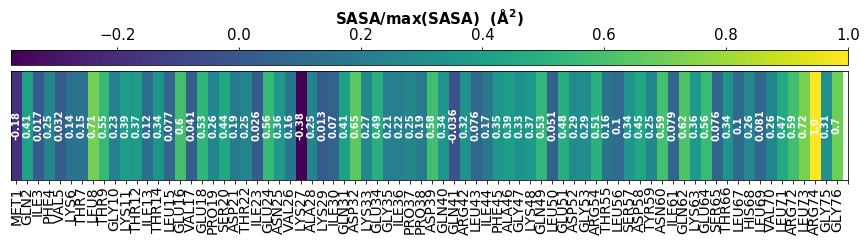

In [52]:
fig_SASA_NVT_Cf02ps = _plot_SASAHeatmap(SURFAlldf_Cf02ps, UBQatom_df)
fig_SASA_NVT_Cf02ps.savefig('{}Ubiquitin/Analysis/NVT_CF02ps_SASA_Heatmap_Normalized.png'.format(CorrFuncLoc2),
                       dpi=600, bbox_inches='tight')

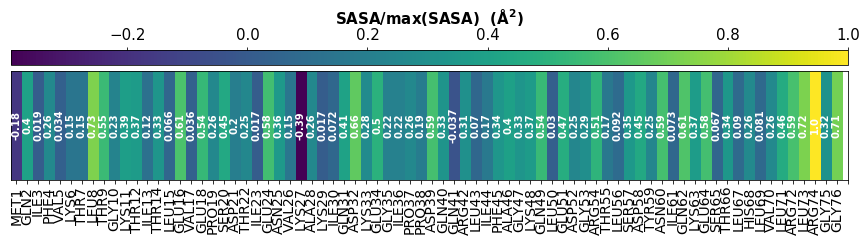

In [54]:
fig_SASA_NVT_Cf2ps = _plot_SASAHeatmap(SURFAlldf_Cf2ps, UBQatom_df)
fig_SASA_NVT_Cf2ps.savefig('{}Ubiquitin/Analysis/NVT_CF2ps_SASA_Heatmap_Normalized.png'.format(CorrFuncLoc2),
                       dpi=600, bbox_inches='tight')

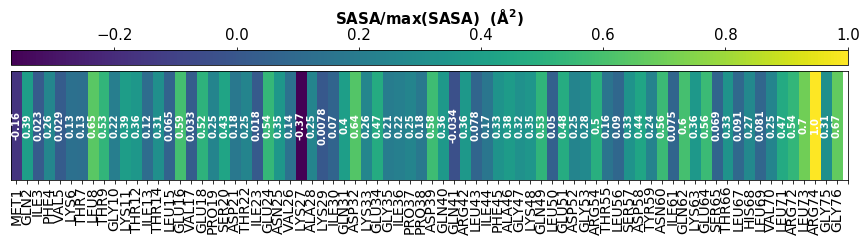

In [53]:
fig_SASA_NVT_Cf20ps = _plot_SASAHeatmap(SURFAlldf_Cf20ps, UBQatom_df)
fig_SASA_NVT_Cf20ps.savefig('{}Ubiquitin/Analysis/NVT_CF20ps_SASA_Heatmap_Normalized.png'.format(CorrFuncLoc2),
                       dpi=600, bbox_inches='tight')

In [ ]:
fig_SASA_NVT_Cf02ps = _plot_SASAHeatmap(SURFAlldf_Cf02ps, UBQatom_df)

In [ ]:
SURFAlldf.mean(axis=0).unstack().columns

In [ ]:

RunsMINDX = pd.MultiIndex.from_product([RUNS, UBQatom_df.RESID])
SURFAlldf = pd.DataFrame(index=np.arange(1, 1000001, 1), columns=RunsMINDX)

for R in RUNS:
    
    for resid in UBQatom_df.RESID:
        fileloc = '{}Ubiquitin/PROD_NVE_Run2/Analysis/{}/Surface/Surface_Res{}.dat'.format(CorrFuncLoc2, R, resid)
        surfdf = pd.read_csv(fileloc, delim_whitespace=True, index_col=0 )
        SURFAlldf[(R,resid)] = surfdf.loc[SURFAlldf.index, 'R{}'.format(resid)]

In [ ]:
SURFAlldf

In [92]:
## Read SASA PDBs:
SASAList = ['Defensin/2LZI', 'TRPCage/1L2Y', 'SHK/1ROO', 'GB3/1p7e',
            'BPTI/1pit', 'Ubiquitin/1UBQ', 'RibonucleaseT1/1YGW', 'HEWL/1E8L']
reference_SASA_dict = {'ALA':106,'ARG':248,'ASN':157,'ASP':163,
                      'CYS':135,'GLN':198,'GLU':194,'GLY':84,
                      'HIS':184,'ILE':169,'LEU':164,'LYS':205,
                      'MET':188,'PHE':197,'PRO':136,'SER':130,
                      'THR':142,'TRP':227, 'TYR':222,'VAL':142}

106, 248, 157, 163, 135, 198, 194, 84, 184,169, 164, 205, 188, 197, 136, 130, 142, 227, 222, and 142 Å2 for 
Ala, Arg, Asn, Asp, Cys, Gln, Glu, Gly, His, Ile, Leu, Lys, Met, Phe, Pro, Ser, Thr, Trp, Tyr, and Val

In [135]:
def _fig_SASA_pdb(data_arr, prot_key, fnum=1):
    
    fsize = len(data_arr[0])*0.25
    fig_SASA = plt.figure(fnum, figsize=(fsize, fsize/30))
    #cmapax = fig_SASA.add_axes([0.125,0.925,0.775,0.10])
    axSASA = fig_SASA.add_subplot(111)

    cmap = axSASA.imshow(data_arr[2][np.newaxis,:], cmap='binary', aspect='auto', vmin=-0.75, vmax=1.0)
    #fig_SASA.colorbar(cmap,cax=cmapax,orientation='horizontal')
    axSASA.set_yticks([])
    #axSASA.set_xticks([])
    axSASA.set_xticks(np.arange(0,len(data_arr[2]),1))
    #axSASA.set_xticklabels(data_arr[0], rotation=90)
    axSASA.set_xticklabels([])
    #cmapax.xaxis.tick_top()
    #cmapax.tick_params(labelsize=15)
    axSASA.tick_params(labelsize=14)
    #cmapax.xaxis.set_label_position('top')
    axSASA.set_xlabel(r'$\mathbf{1-SASA^{DSSP}/SASA^{ref}}$', fontsize=15)
    
    #for j, val in enumerate(data_arr[2]):
        #print(j,val)
    #    text = axSASA.text(j, 0, '{:.2}'.format(val), ha="center", va="center",
    #                       color="w", rotation=90, fontweight='bold')
        
    return fig_SASA

In [110]:
fig_SASA = plt.figure(, figsize=(15,2.0))
#cmapax = fig_SASA.add_axes([0.125,0.925,0.775,0.10])
axSASA = fig_SASA.add_subplot(111)

cmap = axSASA.imshow(SASAdict['GB3'][2][np.newaxis,:], cmap='viridis', aspect='auto')
#fig_SASA.colorbar(cmap, cax=cmapax, orientation='horizontal')
axSASA.set_yticks([])
axSASA.set_xticks(np.arange(0,len(SASAdict['GB3'][2]),1))
axSASA.set_xticklabels(SASAdict['GB3'][0], rotation=90)
cmapax.xaxis.tick_top()
cmapax.tick_params(labelsize=15)
axSASA.tick_params(labelsize=14)
cmapax.xaxis.set_label_position('top')
#cmapax.set_xlabel(r'$\mathbf{SASA/SASA^{ref} \ \ (\AA^{2})}$', fontsize=15)

for j, val in enumerate(sasa_ref.flatten()):
        #print(j,val)
        text = axSASA.text(j, 0, '{:.2}'.format(val), ha="center", va="center", color="w", rotation=90, fontweight='bold')
        
#fig_SASA.savefig('{}Ubiquitin/PROD_NVE/Analysis/SASA_Heatmap_Avg_Normalized.png'.format(CorrFuncLoc2), dpi=600, bbox_inches='tight')

SyntaxError: invalid syntax (<ipython-input-110-93c8da91692b>, line 1)

In [111]:
SASAdict = {}
for prot in SASAList:
    sasaseries = pd.read_fwf('{}/{}_dssp.dat'.format(CorrFuncLoc2, prot), skiprows=27)['ACC']
    pdb = md.load_pdb('{}{}.pdb'.format(CorrFuncLoc2, prot))
    ca_atoms = pdb.topology.select('name CA and protein')
    resname = ['{}'.format(pdb.topology.atom(atind)).split('-')[0] for atind in ca_atoms]
    ref_seqseries = pd.Series(resname).apply(lambda res: res[:3]).replace(reference_SASA_dict)
    SASAdict[prot.split('/')[0]] = [resname, sasaseries.values, (1-sasaseries/ref_seqseries).values]

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\mdtraj\formats\pdb\pdbfile.py:196: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn('Unlikely unit cell vectors detected in PDB file likely '


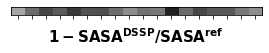

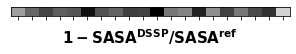

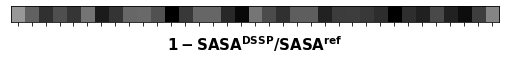

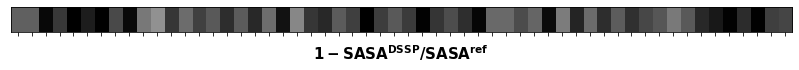

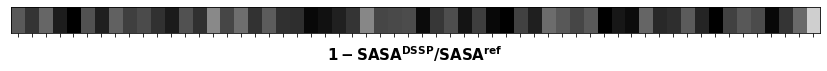

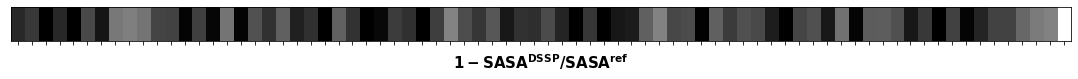

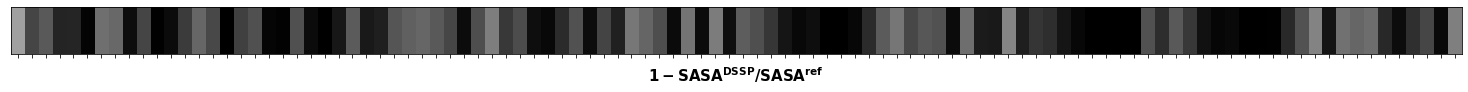

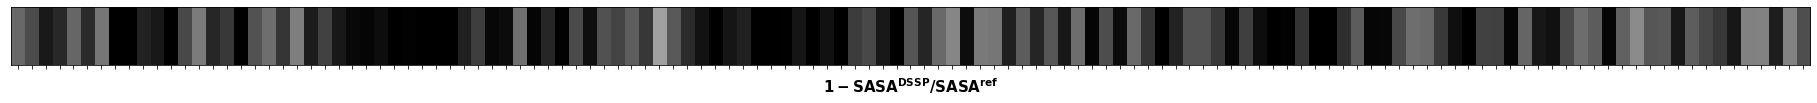

In [136]:
for nk, pkey in enumerate(SASAdict.keys()):
    sasa_fig = _fig_SASA_pdb(SASAdict[pkey], pkey, fnum=nk)
    sasa_fig.savefig('{}{}/{}_SASA_PDB_Heatmap_gray.png'.format(CorrFuncLoc2, pkey, pkey),
                     dpi=600, bbox_inches='tight')

In [82]:
SASASeries = pd.read_fwf('{}/{}_dssp.dat'.format(CorrFuncLoc2, SASAList[2]), skiprows=27)

In [84]:
SASASeries

,# RESIDUE,AA,STRUCTURE,BP1,BP2,ACC,N-H-->O,O-->H-N,N-H-->O.1,O-->H-N.1,TCO,KAPPA ALPHA PHI PSI,X-CA,Y-CA,Z-CA
0,1 1 A,R,NaN,0,0,258,"0, 0.0","2,-0.4","0, 0.0","0, 0.0",0.000,360.0 360.0 360.0-178.8,1.6,0.0,-3.7
1,2 2 A,S,-,0,0,87,"2,-0.0","2,-0.7","0, 0.0","27,-0.0",-0.932,360.0-125.8-122.2 145.7,4.5,-2.5,-3.7
2,3 3 A,a,+,0,0,45,"-2,-0.4","27,-0.3","27,-0.1","2,-0.3",-0.813,47.0 147.4 -93.6 111.4,6.3,-4.0,-0.7
3,4 4 A,I,-,0,0,92,"-2,-0.7","2,-0.3","22,-0.1","25,-0.3",-0.871,28.7-154.1-138.2 171.7,10.1,-3.5,-1.0
4,5 5 A,D,-,0,0,60,"-2,-0.3","23,-0.3","24,-0.3","22,-0.2",-0.995,22.2-151.1-146.5 148.1,13.2,-2.9,1.0
5,6 6 A,T,S S+,0,0,113,"21,-2.2","22,-0.1","1,-0.4","21,-0.1",0.669,104.4 7.3 -89.6 -19.2,16.6,-1.3,0.6
6,7 7 A,I,S S-,0,0,32,"20,-1.4","-1,-0.4","16,-0.1","2,-0.1",-0.926,78.7-169.6-150.6 144.9,17.7,-3.9,3.3
7,8 8 A,P,> -,0,0,49,"0, 0.0","3,-2.4","0, 0.0","4,-0.1",-0.021,69.3 -15.6-108.6-137.9,15.5,-6.7,4.6
8,9 9 A,K,G > S+,0,0,145,"1,-0.3","3,-1.6","2,-0.2","8,-0.1",0.697,118.5 85.7 -36.0 -32.1,16.1,-9.0,7.5
9,10 10 A,S,G 3 S+,0,0,94,"1,-0.3","-1,-0.3","3,-0.0","3,-0.0",0.878,114.0 8.5 -46.0 -48.9,19.7,-7.9,7.3


### Figure 2 Preparation:
### Rotational Correlation Time w/ Scaling


In [37]:
avg_RotDifDF = pd.read_excel('{}TIP4P-D_Diffusion_Results 12-21.xlsx'.format(CorrFuncLoc2),
              sheet_name='Summary of Results', skiprows=3, header=[0,1])
avg_RotDifDF = avg_RotDifDF.drop(columns=[('Unnamed: 0_level_0', 'Unnamed: 0_level_1'), ('Unnamed: 1_level_0', 'Unnamed: 1_level_1')])

In [84]:
avg_RotDifDF.iloc[:,[0,1,2,4,6]].dropna()

,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,Avg NVE,Avg NVT
,Protein Name:,# of Residues,exp corr time (ns),avg sim corrr time (ns),avg sim corrr time (ns)
0,θ-Defensins,18.0,1.00,1.252396,2.173098
4,Trp-Cage,20.0,1.10,0.955351,1.535645
8,ShK,36.0,2.50,3.407500,5.470464
12,GB3,56.0,3.43,3.220000,6.090000
16,BPTI,58.0,3.50,4.125255,7.416159
20,Ubiquitin,76.0,4.10,4.332500,8.767500
24,Ribonuclease T1,104.0,5.30,4.732500,10.870575
28,Lysozyme,129.0,5.70,5.816629,13.466433


In [85]:
avg_RotDifDF_4Plot = avg_RotDifDF.iloc[:, [0, 1, 2, 4, 6]].dropna()
avg_RotDifDF_4Plot_Scl = avg_RotDifDF.iloc[:, [0, 1, 2, -3, -1]].dropna()


In [108]:
import statsmodels.api as sm

In [1]:
NVT2Exp = sm.OLS(avg_RotDifDF_4Plot.iloc[:,4].values, avg_RotDifDF_4Plot.iloc[:,2].values)

NVT2Exp_fit = NVT2Exp.fit()
sNVT2Exp = sm.OLS(avg_RotDifDF_4Plot_Scl.iloc[:,-1].values, avg_RotDifDF_4Plot.iloc[:,2].values)
sNVT2Exp_fit = sNVT2Exp.fit()

NameError: name 'sm' is not defined

In [122]:
avg_RotDifDF_4Plot_Scl.iloc[:,-1].values

array([1.35418139, 0.9811113 , 3.02374432, 3.29620368, 3.84296412,
       4.35417427, 5.07028851, 5.84247598])

In [121]:
sNVT2Exp_fit.predict(avg_RotDifDF_4Plot.iloc[:,2].values)

array([1.02649595, 1.12914554, 2.56623986, 3.52088109, 3.59273581,
       4.20863338, 5.44042851, 5.85102689])

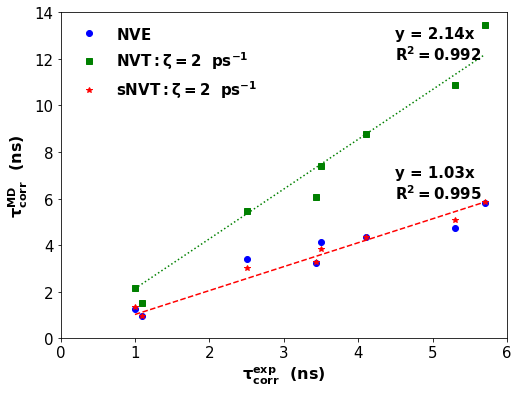

In [155]:
fig_avgRotCorr = plt.figure(3101, figsize=(8,6))
axTcorr = fig_avgRotCorr.add_subplot(111)

axTcorr.plot(avg_RotDifDF_4Plot.iloc[:,2], avg_RotDifDF_4Plot.iloc[:,3], linestyle='', marker='o', color='b',
             label=r'$\mathbf{NVE}$')
axTcorr.plot(avg_RotDifDF_4Plot.iloc[:,2], avg_RotDifDF_4Plot.iloc[:,4], linestyle='', marker='s', color='g',
             label=r'$\mathbf{NVT : \zeta = 2 \ \ ps^{-1}}$')
axTcorr.plot(avg_RotDifDF_4Plot.iloc[:,2], NVT2Exp_fit.predict(avg_RotDifDF_4Plot.iloc[:,2].values),
             linestyle=':', marker='', color='g')
axTcorr.text(4.5, 12,'y = {:.3}x'.format(NVT2Exp_fit.params[0])+'\n'+ r'$\mathbf{{R^{{2}} = {:.3}}}$'.format(NVT2Exp_fit.rsquared),
             weight='bold',fontsize=15)

axTcorr.plot(avg_RotDifDF_4Plot_Scl.iloc[:,2], avg_RotDifDF_4Plot_Scl.iloc[:,-1], linestyle='', marker='*', color='r',
             label=r'$\mathbf{sNVT : \zeta = 2 \ \ ps^{-1}}$')
axTcorr.plot(avg_RotDifDF_4Plot_Scl.iloc[:,2], sNVT2Exp_fit.predict(avg_RotDifDF_4Plot.iloc[:,2].values),
             linestyle='--', marker='', color='r')

axTcorr.text(4.5, 6,'y = {:.3}x'.format(sNVT2Exp_fit.params[0])+'\n'+ r'$\mathbf{{R^{{2}} = {:.3}}}$'.format(sNVT2Exp_fit.rsquared),
             weight='bold',fontsize=15)

axTcorr.legend(frameon=False, prop={'size':15})
axTcorr.tick_params(labelsize=15)
axTcorr.set_xlabel(r'$\mathbf{\tau^{exp}_{corr} \ \ (ns)}$', fontsize=16)
axTcorr.set_ylabel(r'$\mathbf{\tau^{MD}_{corr} \ \ (ns)}$', fontsize=16)
axTcorr.set_xlim(0,6)
axTcorr.set_ylim(0,14)
fig_avgRotCorr.savefig('{}AvgScaledRotationalCorrelationTime_LinearOLS.png'.format(CorrFuncLoc2), dpi=600, bbox_inches='tight')

In [66]:
avg_RotDifDF_4Plot_Scl

Unnamed: 2_level_0 Unnamed: 3_level_0   Avg NVT          
                 Protein Name:      # of Residues   NVT/NVE NVT/NVE.2
0                  θ-Defensins               18.0  1.735152  1.354181
1                          NaN                NaN       NaN       NaN
2                          NaN                NaN       NaN       NaN
3                          NaN                NaN       NaN       NaN
4                     Trp-Cage               20.0  1.607414  0.981111
5   (first set of NVT results)                NaN       NaN       NaN
6                          NaN                NaN       NaN       NaN
7                          NaN                NaN       NaN       NaN
8                          ShK               36.0  1.605419  3.023744
9                          NaN                NaN       NaN       NaN
10                         NaN                NaN       NaN       NaN
11                         NaN                NaN       NaN       NaN
12                         GB3               56.0  1.891304  3.296204
13                         NaN                NaN       NaN       NaN
14                         NaN                NaN       NaN       NaN
15                         NaN                NaN       NaN       NaN
16                        BPTI               58.0  1.797746  3.842964
17                         NaN                NaN       NaN       NaN
18                         NaN                NaN       NaN       NaN
19                         NaN                NaN       NaN       NaN
20                   Ubiquitin               76.0  2.023658  4.354174
21                         NaN                NaN       NaN       NaN
22                         NaN                NaN       NaN       NaN
23                         NaN                NaN       NaN       NaN
24             Ribonuclease T1              104.0  2.297005  5.070289
25                         NaN                NaN       NaN       NaN
26                         NaN                NaN       NaN       NaN
27                         NaN                NaN       NaN       NaN
28                    Lysozyme              129.0  2.315161  5.842476
29                         NaN                NaN       NaN       NaN
30                         NaN                NaN       NaN       NaN
31                         NaN                NaN       NaN       NaN